# **TP2 Ciencia de Datos: Clasificación de Intenciones**
**Objetivo:** Desarrollar un modelo capaz de clasificar intenciones a partir de consultas en inglés utilizando el dataset `intent.csv` (77 categorías).

## Importación de Librerías y Configuración

In [250]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet
import spacy
import gensim
from gensim.models import Word2Vec
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

True

## Funciones Auxiliares de Preprocesamiento de Texto

Se definen a continuación las funciones de limpieza y normalización del texto.
Se declaran aquí —junto a los imports— porque se utilizan tanto en la **Etapa 1 (EDA)**
(nube de palabras, vocabulario exclusivo) como en la **Etapa 2 (Preprocesamiento)**
(vectorización TF-IDF).

El proceso incluye:
- **Lowercase** y eliminación de caracteres especiales.
- **Tokenización** y eliminación de *stop words* en inglés.
- **Lematización** con `WordNetLemmatizer` (NLTK), respetando la categoría gramatical de cada token.

El resultado se almacena en la columna `text_clean`.

In [251]:
def clean_text(text: str) -> str:
    """
    Preprocesa texto en inglés para vectorización con TF-IDF:
      1. Lowercase
      2. Eliminación de URLs
      3. Eliminación de caracteres no alfanuméricos
      4. Tokenización
      5. POS tagging (para lemmatización precisa de verbos y sustantivos)
      6. Eliminación de stopwords y tokens cortos (< 2 chars)
      7. Lemmatización con POS (varía lemmatización dependiendo del tipo de palabra)

    NO usar con SBERT/embeddings (rompe el contexto semántico).
    """
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    tokens = word_tokenize(text)
    pos_tags = pos_tag(tokens)
    tokens = [
        _lemmatizer.lemmatize(token, pos=get_wordnet_pos(tag))
        for token, tag in pos_tags
        if token not in _stop_words and len(token) > 1
    ]
    return ' '.join(tokens)

# Preprocesamiento (solo para TF-IDF) ---
df['text_clean'] = df['text'].apply(clean_text)

# Verificación
# print("Original :", df['text'].iloc[0])
# print("Limpio   :", df['text_clean'].iloc[0])

In [252]:
_lemmatizer = WordNetLemmatizer()
_stop_words = set(stopwords.words('english'))

def get_wordnet_pos(treebank_tag: str) -> str:
    """Convierte POS tag de NLTK (Treebank) a formato WordNet para lemmatización.
    """
    if treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default: sustantivo

# Etapa 1 — Análisis Exploratorio de Datos (EDA)

En esta etapa se realiza un análisis exhaustivo del dataset **intent.csv** para
comprender su estructura, distribución y características principales.

1. **Carga y descripción del dataset:** dimensiones, tipos de datos y valores nulos.
2. **Distribución de clases:** frecuencia y balance de las 77 intenciones.
3. **Nube de palabras:** términos más frecuentes en el corpus.
4. **Análisis de longitud de los mensajes:** distribución de `word_count` y `char_count`.
5. **Correlación entre variables numéricas.**
6. **Distribución de `avg_word_length` por clase.**
7. **Vocabulario exclusivo por clase.**

El dataset se encuentra en el archivo `intent.csv` y contiene las variables:
- **`text`**: mensaje original del usuario (en inglés).
- **`category`**: intención detectada (77 categorías posibles).

In [253]:
df = pd.read_csv("./Documentos/intent.csv")

print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nPrimeras filas:")
df.head()

Dimensiones del dataset: 13083 filas x 2 columnas

Primeras filas:


,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


In [254]:
# ── Variables numéricas derivadas del texto ─────────────────────────────────
df["word_count"]     = df["text"].astype(str).apply(lambda x: len(x.split()))
df["char_count"]     = df["text"].astype(str).apply(len)
df["avg_word_length"] = df["char_count"] / df["word_count"]

# ── Texto normalizado y lematizado (usado en EDA y vectorización) ────────────
# clean_text está definida en "Funciones Auxiliares" al inicio del notebook
df["text_clean"] = df["text"].apply(clean_text)

print("=== Estadísticas de longitud ===")
print(df[["word_count", "char_count", "avg_word_length"]].describe().round(2))
print(f"\nColumna text_clean creada: {df['text_clean'].notna().sum()} registros procesados")


=== Estadísticas de longitud ===
       word_count  char_count  avg_word_length
count    13083.00    13083.00         13083.00
mean        11.71       58.24             4.99
std          7.64       39.56             0.69
min          2.00       13.00             3.00
25%          7.00       36.00             4.50
50%         10.00       46.00             4.94
75%         13.00       63.00             5.40
max         79.00      433.00            10.00

Columna text_clean creada: 13083 registros procesados


**Información general del dataset: tipos de datos y memoria:**

In [255]:
print("=== Información del DataFrame ===")
df.info()

print("\n=== Valores nulos por columna ===")
print(df.isnull().sum())

print(f"\n=== Filas duplicadas: {df.duplicated().sum()} ===")

=== Información del DataFrame ===
<class 'pandas.DataFrame'>
RangeIndex: 13083 entries, 0 to 13082
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   text             13083 non-null  str    
 1   category         13083 non-null  str    
 2   word_count       13083 non-null  int64  
 3   char_count       13083 non-null  int64  
 4   avg_word_length  13083 non-null  float64
 5   text_clean       13083 non-null  str    
dtypes: float64(1), int64(2), str(3)
memory usage: 613.4 KB

=== Valores nulos por columna ===
text               0
category           0
word_count         0
char_count         0
avg_word_length    0
text_clean         0
dtype: int64

=== Filas duplicadas: 0 ===


## Distribución de Clases

Se analiza la distribución de las 77 categorías de intención:
- **Estadísticas:** cantidad mínima, máxima y promedio de muestras por clase.
- **Tabla resumen:** porcentaje de representación de cada categoría.
- **Histograma:** frecuencia de aparición de cada clase, ordenadas de mayor a menor.

In [256]:
class_counts = df["category"].value_counts()
class_pcts   = df["category"].value_counts(normalize=True).mul(100).round(2)

class_summary = pd.DataFrame({
    "Cantidad": class_counts,
    "Porcentaje (%)": class_pcts
})

print(f"Número de categorías únicas: {df['category'].nunique()}")
print(f"\nMínimo de muestras por clase : {class_counts.min()} — Clase: '{class_counts.idxmin()}'")
print(f"Máximo de muestras por clase : {class_counts.max()} — Clase: '{class_counts.idxmax()}'")
print(f"Promedio de muestras por clase: {class_counts.mean():.1f}")
print()

print("\nResumen: ")
class_summary


Número de categorías únicas: 77

Mínimo de muestras por clase : 75 — Clase: 'contactless_not_working'
Máximo de muestras por clase : 227 — Clase: 'card_payment_fee_charged'
Promedio de muestras por clase: 169.9


Resumen: 


,Cantidad,Porcentaje (%)
category,,
card_payment_fee_charged,227,1.74
direct_debit_payment_not_recognised,222,1.70
balance_not_updated_after_cheque_or_cash_deposit,221,1.69
wrong_amount_of_cash_received,220,1.68
cash_withdrawal_charge,217,1.66
...,...,...
lost_or_stolen_card,122,0.93
card_swallowed,101,0.77
card_acceptance,99,0.76


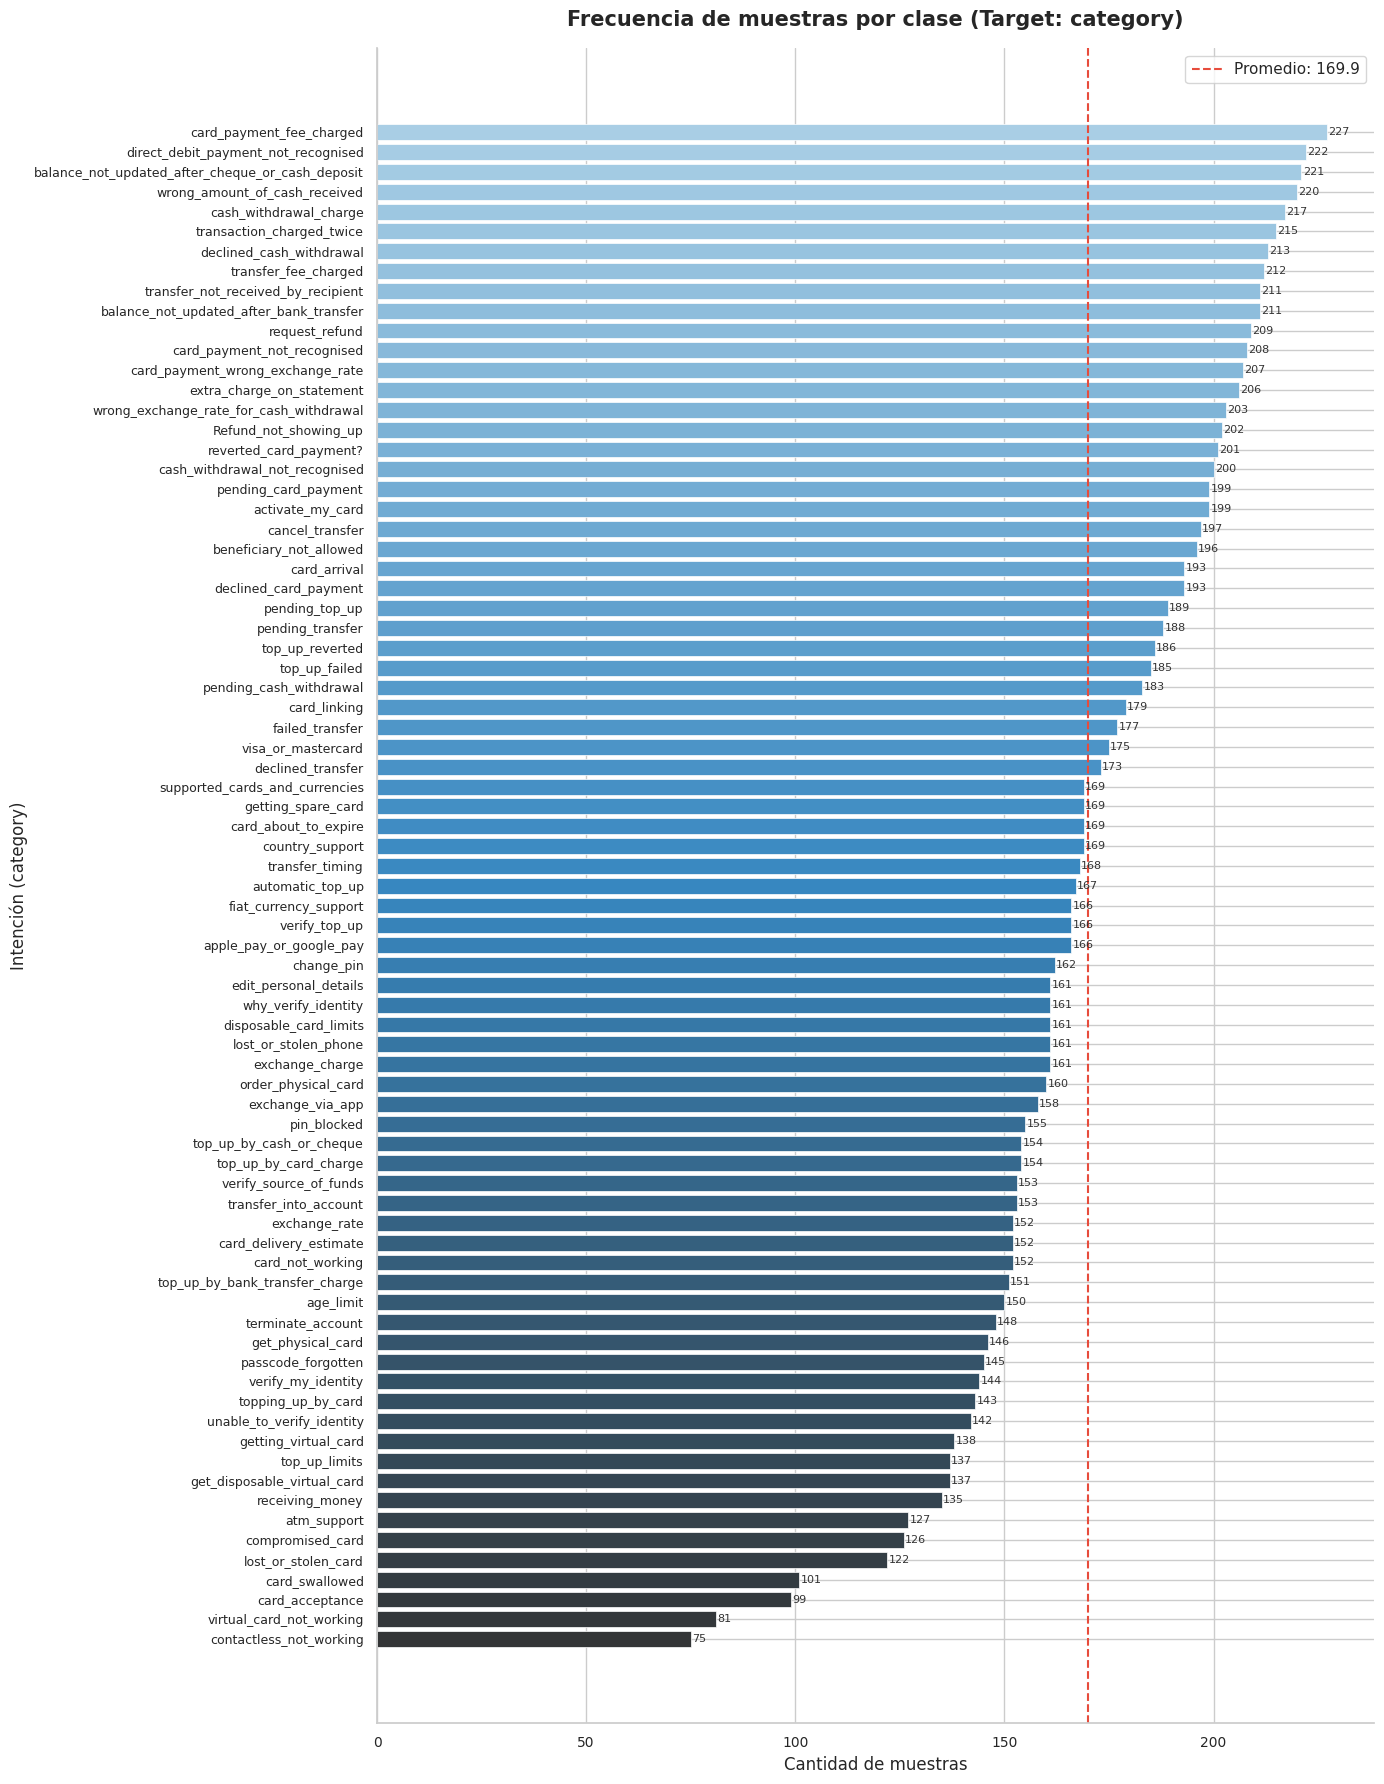

In [257]:
# Histograma de frecuencia por clase (ordenado de mayor a menor)
fig, ax = plt.subplots(figsize=(14, 18))

palette = sns.color_palette("Blues_d", n_colors=len(class_counts))

bars = ax.barh(
    class_counts.index,
    class_counts.values,
    color=palette,
    edgecolor="white",
    linewidth=0.5
)

avg = class_counts.mean()
ax.axvline(avg, color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Promedio: {avg:.1f}")

for bar, count in zip(bars, class_counts.values):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        str(count),
        va="center", ha="left",
        fontsize=8, color="#333333"
    )

ax.set_title("Frecuencia de muestras por clase (Target: category)", fontsize=15, fontweight="bold", pad=16)
ax.set_xlabel("Cantidad de muestras", fontsize=12)
ax.set_ylabel("Intención (category)", fontsize=12)
ax.invert_yaxis()   # la clase más frecuente arriba
ax.legend(fontsize=11)
ax.tick_params(axis="y", labelsize=9)
sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.show()

## Nube de Palabras del Corpus

Se genera una nube de palabras a partir del texto preprocesado (`text_clean`) de todo el corpus.

Las palabras de mayor tamaño son las más frecuentes y permiten identificar los términos dominantes en el vocabulario de las consultas.

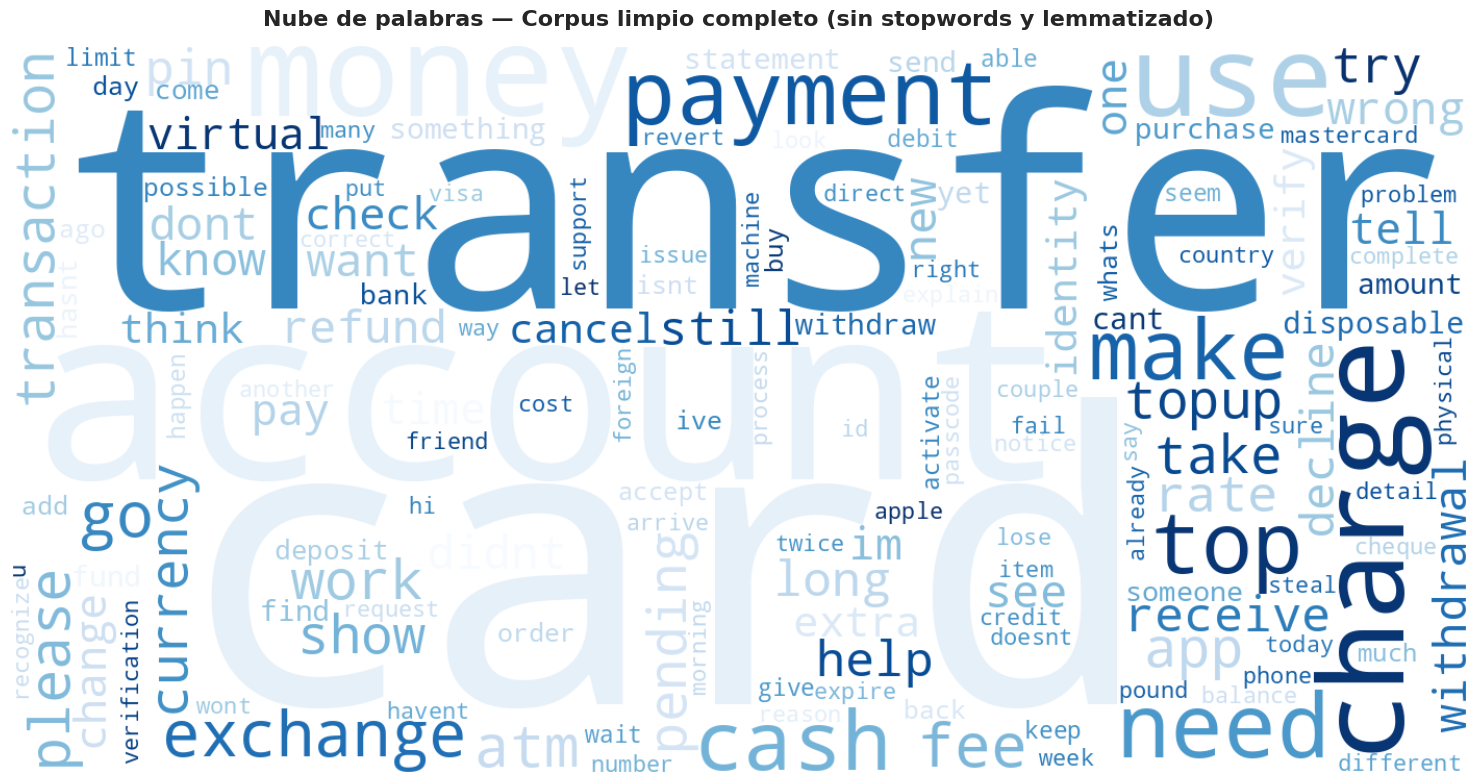

In [258]:
corpus_text = " ".join(df["text_clean"].astype(str).tolist())

wc_global = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    colormap="Blues",
    max_words=150,
    collocations=False,   # evita repetir bigramas
    contour_color="steelblue",
    contour_width=1
).generate(corpus_text)

plt.figure(figsize=(16, 8))
plt.imshow(wc_global, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras — Corpus limpio completo (sin stopwords y lemmatizado)", fontsize=16, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()

## Análisis de Longitud de los Mensajes

Se calculan y visualizan las siguientes métricas derivadas de cada mensaje:
- **`word_count`**: cantidad de palabras en el texto original.
- **`char_count`**: cantidad de caracteres (sin espacios) en el texto original.

Para cada métrica se presenta:
1. **Histograma** con estadísticas descriptivas básicas.
2. **Boxplot por clase** — permite ver si ciertas intenciones tienden a expresarse con mensajes más largos o cortos.
3. **Detección de outliers** — se identifican mensajes atípicos usando el criterio 1.5 × IQR.

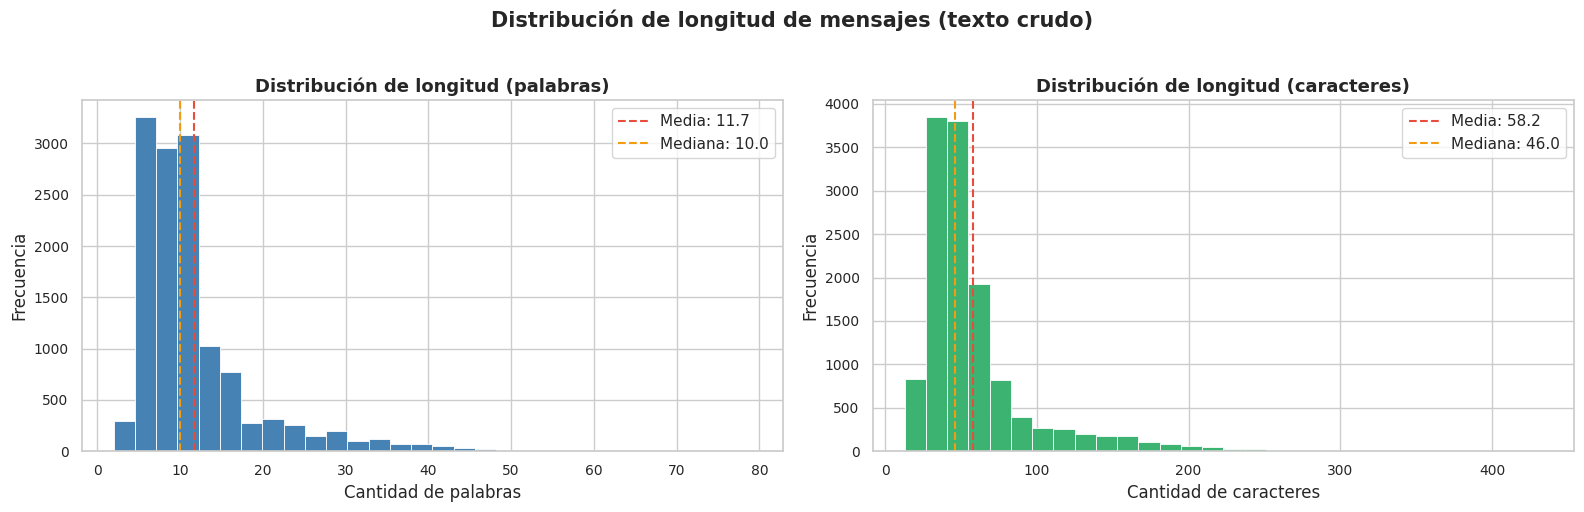

In [259]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# istribución en palabras ---
axes[0].hist(df["word_count"], bins=30, color="steelblue", edgecolor="white", linewidth=0.6)
axes[0].axvline(df["word_count"].mean(),   color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Media: {df['word_count'].mean():.1f}")
axes[0].axvline(df["word_count"].median(), color="#f39c12", linestyle="--", linewidth=1.5, label=f"Mediana: {df['word_count'].median():.1f}")
axes[0].set_title("Distribución de longitud (palabras)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Cantidad de palabras")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# Distribución en caracteres ---
axes[1].hist(df["char_count"], bins=30, color="mediumseagreen", edgecolor="white", linewidth=0.6)
axes[1].axvline(df["char_count"].mean(),   color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Media: {df['char_count'].mean():.1f}")
axes[1].axvline(df["char_count"].median(), color="#f39c12", linestyle="--", linewidth=1.5, label=f"Mediana: {df['char_count'].median():.1f}")
axes[1].set_title("Distribución de longitud (caracteres)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Cantidad de caracteres")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()

plt.suptitle("Distribución de longitud de mensajes (texto crudo)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


/tmp/ipykernel_8278/3057621608.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


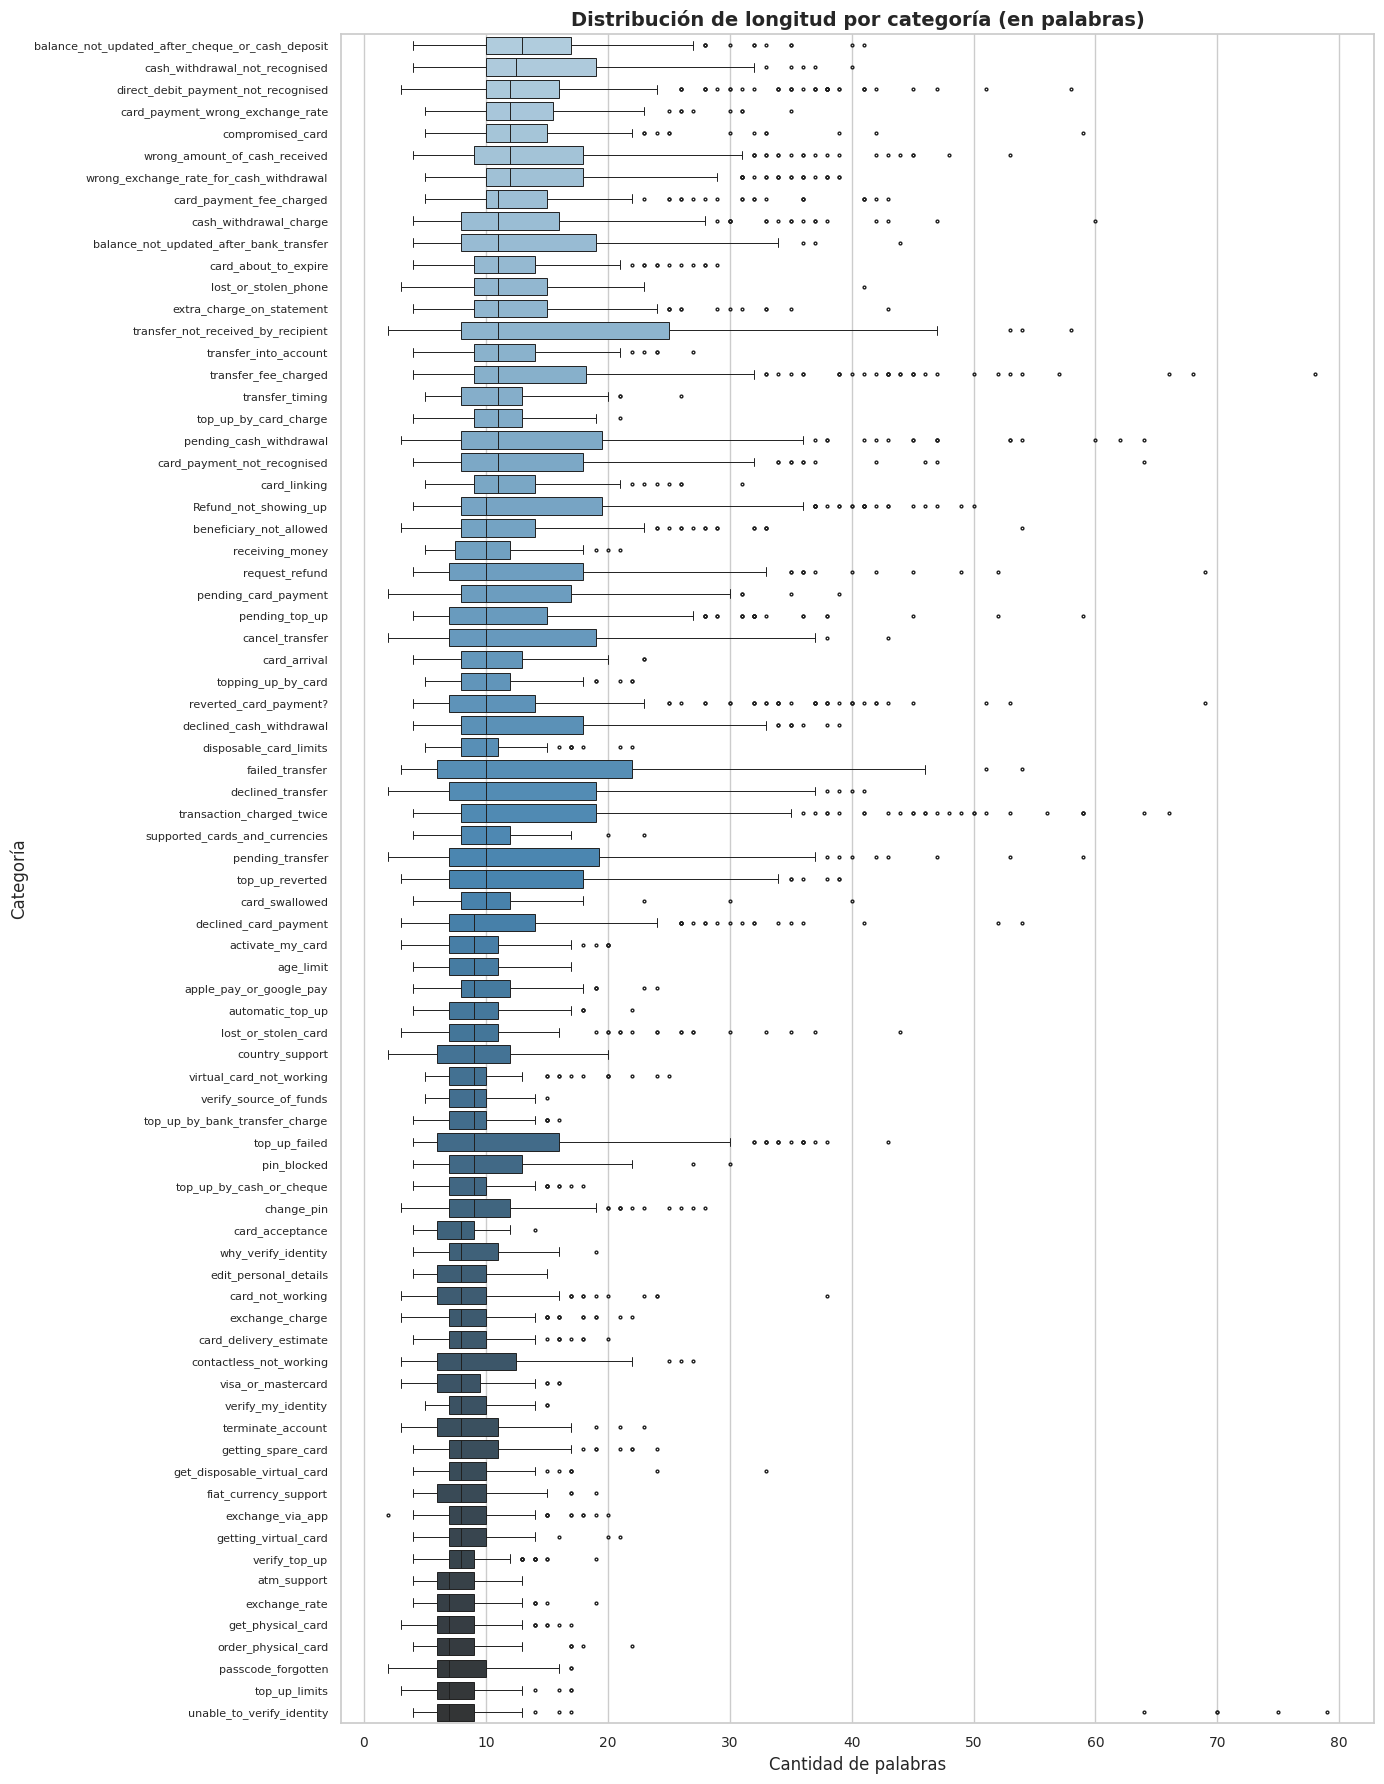

In [260]:
order = (df.groupby("category")["word_count"]
           .median()
           .sort_values(ascending=False)
           .index)

fig, ax = plt.subplots(figsize=(14, 18))
sns.boxplot(
    data=df,
    x="word_count",
    y="category",
    order=order,
    palette="Blues_d",
    linewidth=0.7,
    fliersize=2,
    ax=ax
)
ax.set_title("Distribución de longitud por categoría (en palabras)", fontsize=14, fontweight="bold")
ax.set_xlabel("Cantidad de palabras")
ax.set_ylabel("Categoría")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()


In [261]:
Q1 = df["word_count"].quantile(0.25)
Q3 = df["word_count"].quantile(0.75)
IQR = Q3 - Q1

muy_cortos = df[df["word_count"] <= 3]
muy_largos = df[df["word_count"] > Q3 + 1.5 * IQR]

print(f"Mensajes muy cortos (≤ 3 palabras): {len(muy_cortos)} ({100*len(muy_cortos)/len(df):.2f}%)")
print(f"Mensajes muy largos (> Q3 + 1.5·IQR = {Q3 + 1.5*IQR:.0f} palabras): {len(muy_largos)} ({100*len(muy_largos)/len(df):.2f}%)")

print("\nEjemplos de mensajes muy cortos")
print(muy_cortos[["text", "category", "word_count"]].head(5).to_string(index=False))

print("\nEjemplos de mensajes muy largos")
print(muy_largos[["text", "category", "word_count"]].sort_values("word_count", ascending=False).head(5).to_string(index=False))


Mensajes muy cortos (≤ 3 palabras): 49 (0.37%)
Mensajes muy largos (> Q3 + 1.5·IQR = 22 palabras): 1118 (8.55%)

Ejemplos de mensajes muy cortos
                         text                category  word_count
  withdrawal pending meaning? pending_cash_withdrawal           3
Explain pending transactions. pending_cash_withdrawal           3
           Report stolen card     lost_or_stolen_card           3
         Cancel a transaction         cancel_transfer           3
         stop the transaction         cancel_transfer           3

Ejemplos de mensajes muy largos
                                                                                                                                                                                                                                                                                                                                                                                                                                          

## Correlación entre Variables Numéricas

Se calcula la correlación entre `word_count` y `char_count` mediante dos coeficientes:
- **Pearson** (correlación lineal).
- **Spearman** (correlación por rangos, más robusta ante outliers).

Un coeficiente cercano a 1 indica que ambas variables son altamente redundantes.

--- Correlaciones ---
Coeficiente de Pearson:  0.9840
Coeficiente de Spearman: 0.9423



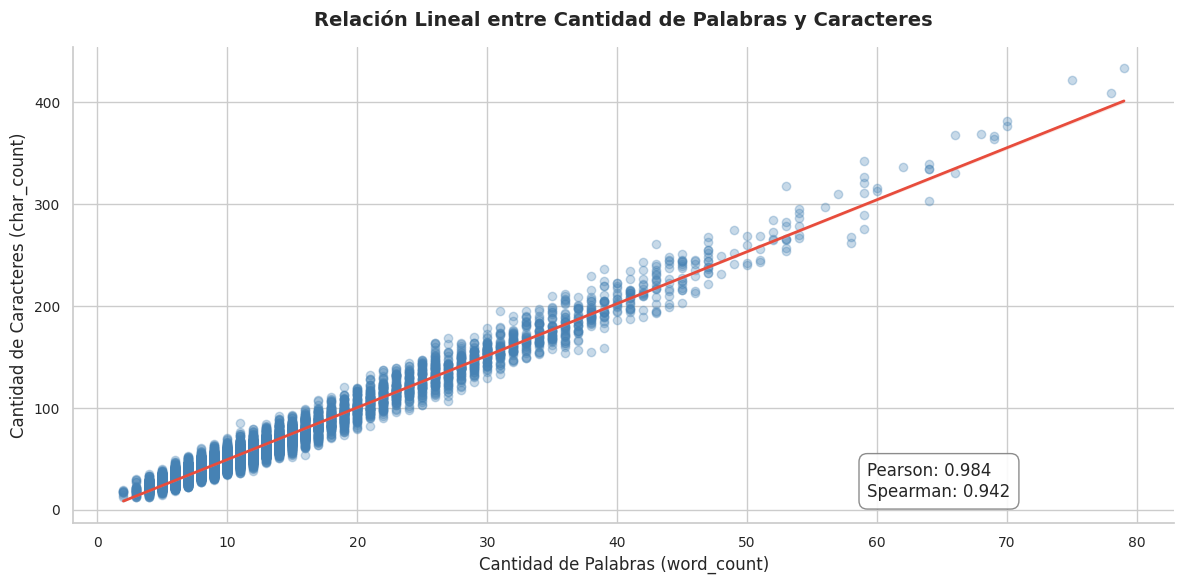

In [262]:
corr_pearson = df['word_count'].corr(df['char_count'], method='pearson')
corr_spearman = df['word_count'].corr(df['char_count'], method='spearman')

print("--- Correlaciones ---")
print(f"Coeficiente de Pearson:  {corr_pearson:.4f}")
print(f"Coeficiente de Spearman: {corr_spearman:.4f}\n")

# Gráfico de dispersión (Scatterplot) con línea de regresión
plt.figure(figsize=(12, 6))
sns.regplot(
    data=df, 
    x="word_count", 
    y="char_count", 
    scatter_kws={"alpha": 0.3, "color": "steelblue"},
    line_kws={"color": "#e74c3c", "linewidth": 2}
)

plt.title("Relación Lineal entre Cantidad de Palabras y Caracteres", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Cantidad de Palabras (word_count)", fontsize=12)
plt.ylabel("Cantidad de Caracteres (char_count)", fontsize=12)

x_pos = df['word_count'].max() * 0.75
y_pos = df['char_count'].min() or 10

plt.text(
    x=x_pos, 
    y=y_pos, 
    s=f"Pearson: {corr_pearson:.3f}\nSpearman: {corr_spearman:.3f}", 
    fontsize=12, 
    bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5')
)

sns.despine()
plt.tight_layout()
plt.show()

### Distribución de `avg_word_length` por Clase

Se visualiza la distribución de la longitud promedio de palabra para cada categoría,
lo que permite verificar si existe diferenciación entre intenciones basada en esta métrica.

/tmp/ipykernel_8278/187612653.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


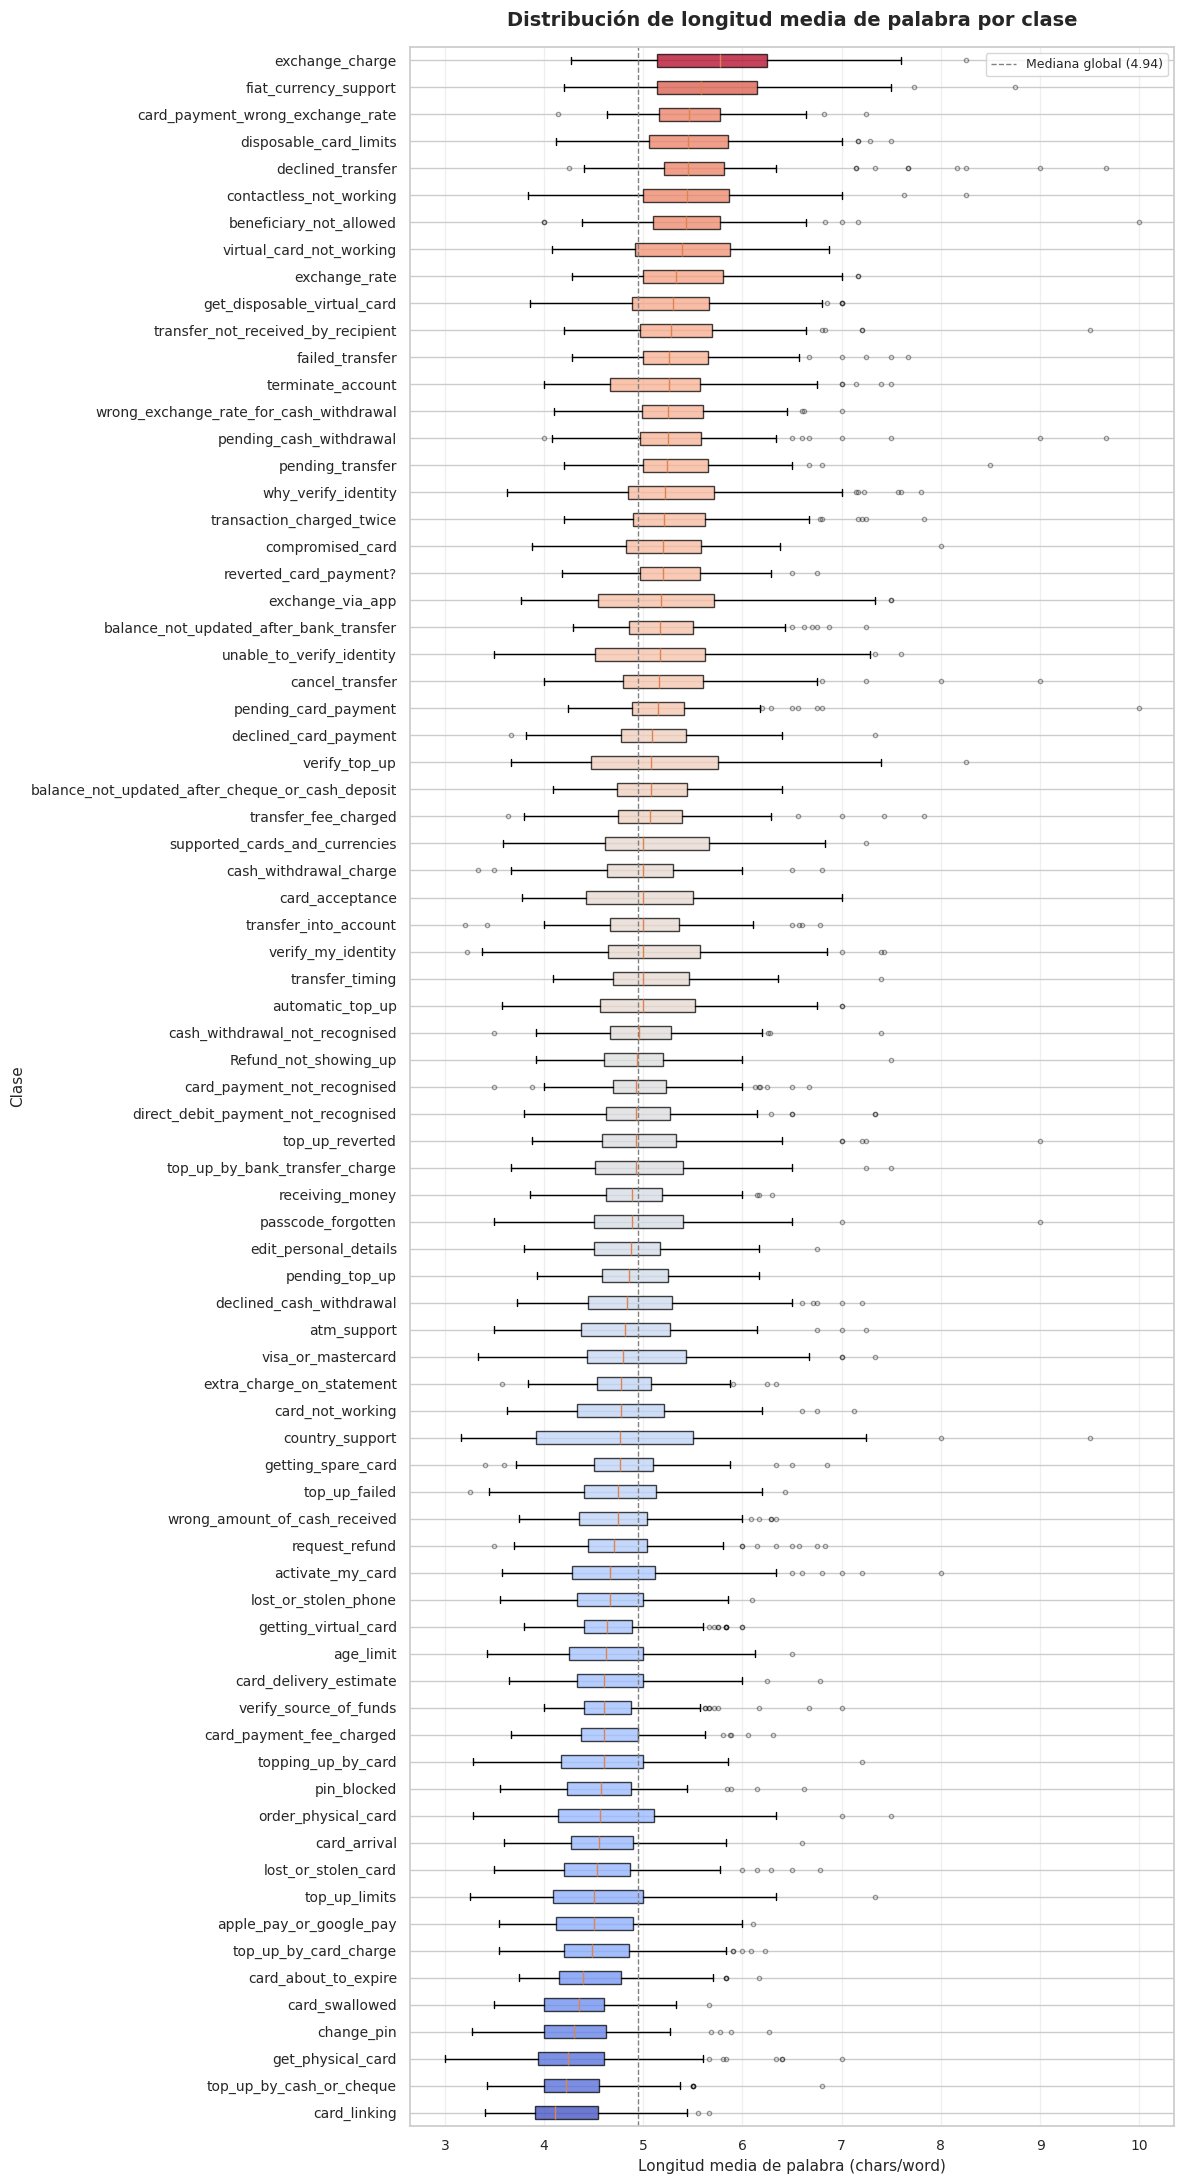

In [263]:
# Ordenar clases por mediana de avg_word_length
orden = (
    df.groupby('category')['avg_word_length']
    .median()
    .sort_values()
)

data_plot = [
    df.loc[df['category'] == clase, 'avg_word_length'].values
    for clase in orden.index
]

fig, ax = plt.subplots(figsize=(12, 22))
bp = ax.boxplot(
    data_plot,
    vert=False,
    patch_artist=True,
    labels=orden.index,
    flierprops=dict(marker='o', markersize=3, alpha=0.4)
)

cmap = plt.cm.coolwarm
medianas = [np.median(d) for d in data_plot]
norm = plt.Normalize(min(medianas), max(medianas))
for patch, med in zip(bp['boxes'], medianas):
    patch.set_facecolor(cmap(norm(med)))
    patch.set_alpha(0.75)

ax.set_title("Distribución de longitud media de palabra por clase", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Longitud media de palabra (chars/word)", fontsize=11)
ax.set_ylabel("Clase", fontsize=11)
ax.axvline(df['avg_word_length'].median(), color='gray', linestyle='--',
           linewidth=1, label=f"Mediana global ({df['avg_word_length'].median():.2f})")
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


### Interpretación de `avg_word_length`

Se analizó `avg_word_length`, pero la **varianza inter-clase es baja**, por lo que su aporte discriminativo es limitado.

Esto sugiere que, a pesar de ser una métrica de complejidad léxica, la estructura sintáctica o semántica de las consultas es más uniforme de lo esperado entre las distintas intenciones. En consecuencia, la longitud promedio de palabra no permite separar de forma robusta las clases del dataset.

No obstante, se mantiene como feature auxiliar ya que, combinada con otras representaciones (p. ej. TF-IDF o embeddings), puede aportar señal marginal al clasificador.

## Vocabulario Exclusivo por Clase

Se analiza qué palabras aparecen **única y exclusivamente** en las consultas de una determinada
intención (clase) y en ninguna otra. Este análisis aporta valor al EDA por dos razones principales:

1. **Discriminabilidad léxica:** cuanto mayor sea el vocabulario exclusivo de una clase, más
   fácil resulta separarla del resto. Si la mayoría de las palabras son compartidas entre clases,
   el clasificador deberá apoyarse en la distribución conjunta del vocabulario (p. ej., TF-IDF)
   antes que en términos únicos.
2. **Selección de features:** identificar los términos exclusivos de cada clase permite construir
   listas de palabras altamente informativas que pueden utilizarse como señales adicionales o para
   filtrar ruido en representaciones de bolsa de palabras.

> **Interpretación del gráfico:** se muestra, para las clases con **mayor vocabulario exclusivo**,
> cuántas palabras distintas pertenecen solamente a esa intención. Una barra alta indica que la clase
> posee terminología propia que el modelo puede aprender a explotar directamente.
> Un vocabulario exclusivo bajo —o nulo— indica que la clase comparte casi todo su léxico con otras
> intenciones, lo que aumenta la dificultad de clasificación.

Total de clases analizadas : 77
Clases CON palabras exclusivas : 77 / 77  (es decir, 77 intenciones tienen al menos 1 término único)
Clases SIN palabras exclusivas : 0 / 77  (todo su léxico es compartido con otras intenciones)
Mediana de palabras exclusivas : 12  (la mitad de las clases tiene ≤ 12 términos únicos)
Media   de palabras exclusivas : 12.9
Máximo  de palabras exclusivas : 42
Mínimo  de palabras exclusivas : 2


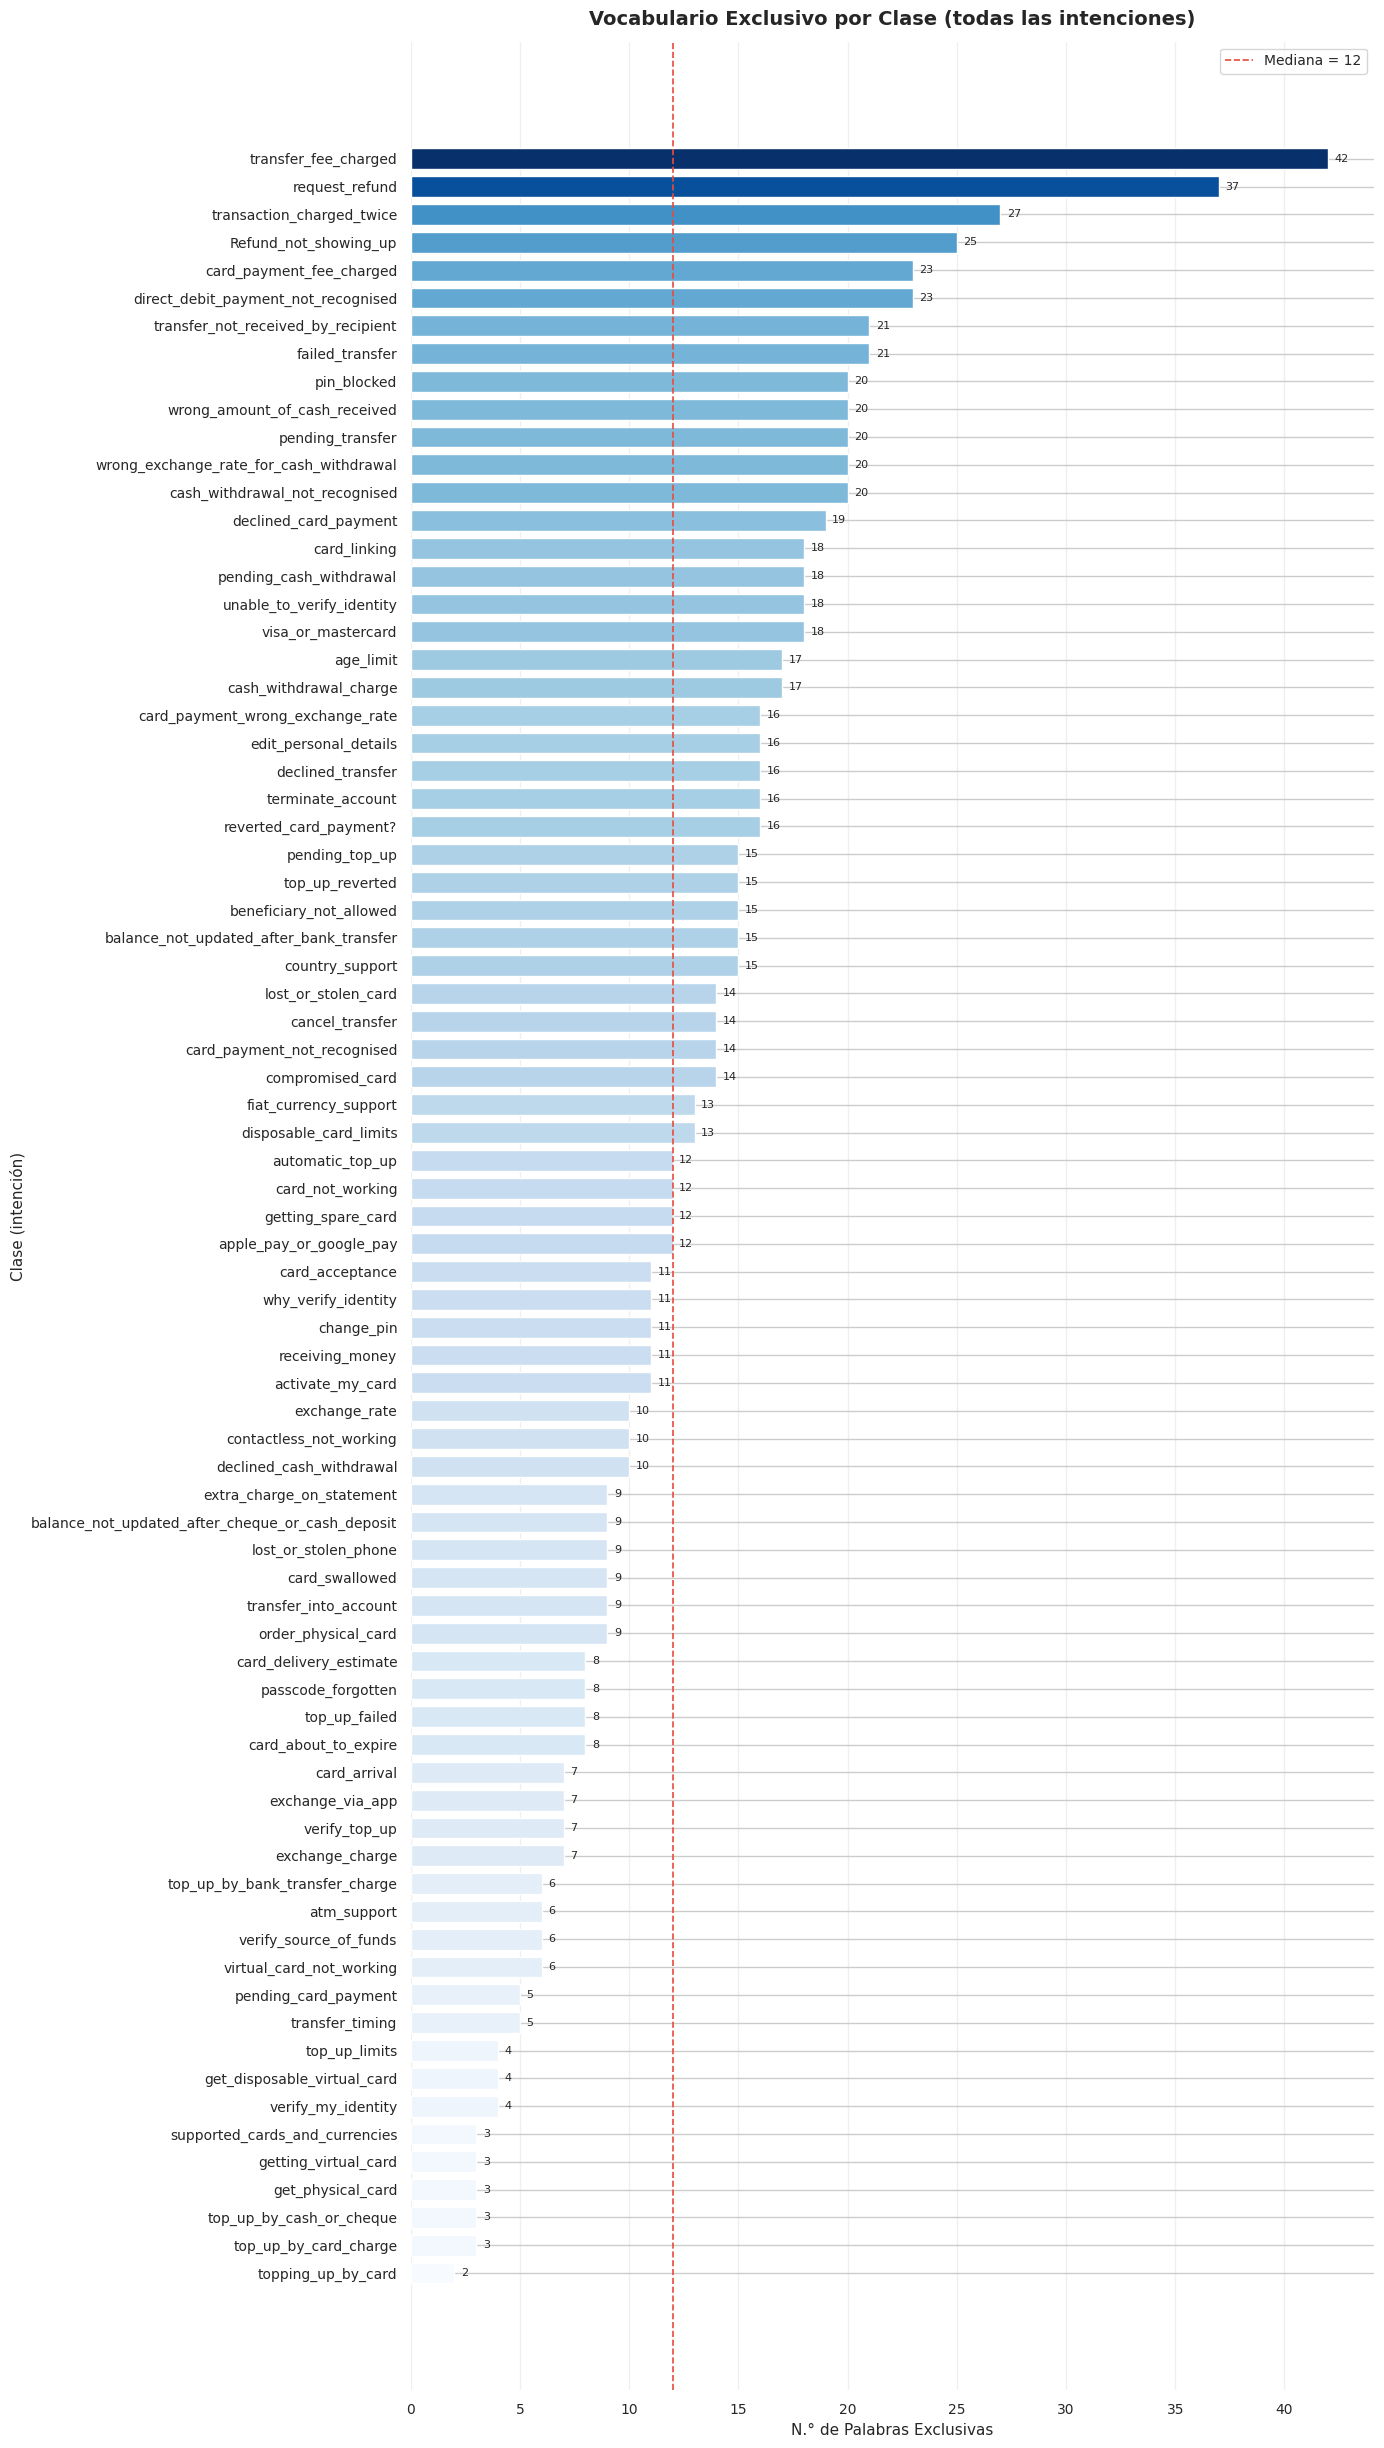


── Muestra de palabras exclusivas (top-10 clases) ──
  [ 42] transfer_fee_charged: ['7000', 'alert', 'alls', 'beach', 'benow', 'bora', 'budget', 'chargged', 'condo', 'crossreference']
  [ 37] request_refund: ['45', 'aggravated', 'begin', 'buyer', 'cancelling', 'chat', 'color', 'competent', 'cry', 'deeply']
  [ 27] transaction_charged_twice: ['attend', 'canada', 'chaged', 'doublecharged', 'duplicated', 'expense', 'fixing', 'fro', 'instore', 'meal']
  [ 25] Refund_not_showing_up: ['accountcould', 'appiled', 'arm', 'assure', 'avail', 'cone', 'creditrefund', 'dress', 'fan', 'frustrated']
  [ 23] card_payment_fee_charged: ['10000', 'additionally', 'advertise', 'clarify', 'feefree', 'forewarn', 'format', 'hell', 'impose', 'instance']
  [ 23] direct_debit_payment_not_recognised: ['authorized', 'boyfriend', 'diret', 'discrepancy', 'disputable', 'fairly', 'largeish', 'legit', 'listing', 'mad']
  [ 21] transfer_not_received_by_recipient: ['completion', 'confusion', 'didint', 'durham', 'friday',

In [264]:
# ─── 1. Construir el vocabulario por clase ───────────────────────────────────
# Usamos text_clean (ya normalizado/lematizado) para mayor coherencia
class_vocab = defaultdict(set)

for _, row in df.iterrows():
    tokens = str(row["text_clean"]).split()
    class_vocab[row["category"]].update(tokens)

# ─── 2. Calcular las clases ──────────────────────────────────────────────────
all_classes = list(class_vocab.keys())

# ─── 3. Vocabulario exclusivo: palabras que sólo aparecen en UNA clase ──────
exclusive_vocab = {}

for cls in all_classes:
    # Unión de vocabularios de TODAS las otras clases
    other_vocab = set().union(
        *[class_vocab[other] for other in all_classes if other != cls]
    )
    exclusive_vocab[cls] = class_vocab[cls] - other_vocab

# ─── 4. Estadísticas resumidas ──────────────────────────────────────────────
exclusive_counts = {
    cls: len(words) for cls, words in exclusive_vocab.items()
}

# Clases con vocabulario exclusivo nulo
zero_exclusive = sum(1 for v in exclusive_counts.values() if v == 0)
n_classes = len(all_classes)
sorted_values = sorted(exclusive_counts.values())
mediana = sorted_values[n_classes // 2]
media = sum(sorted_values) / n_classes

print(f"Total de clases analizadas : {n_classes}")
print(f"Clases CON palabras exclusivas : {n_classes - zero_exclusive} / {n_classes}  "
      f"(es decir, {n_classes - zero_exclusive} intenciones tienen al menos 1 término único)")
print(f"Clases SIN palabras exclusivas : {zero_exclusive} / {n_classes}  "
      f"(todo su léxico es compartido con otras intenciones)")
print(f"Mediana de palabras exclusivas : {mediana}  "
      f"(la mitad de las clases tiene ≤ {mediana} términos únicos)")
print(f"Media   de palabras exclusivas : {media:.1f}")
print(f"Máximo  de palabras exclusivas : {sorted_values[-1]}")
print(f"Mínimo  de palabras exclusivas : {sorted_values[0]}")

# ─── 5. Visualización: TODAS las clases ordenadas de mayor a menor ───────────
sorted_classes = sorted(exclusive_counts.items(), key=lambda x: x[1], reverse=True)
labels, counts = zip(*sorted_classes)

# Altura dinámica: ~0.32 px por clase para que quepan los 77 nombres
fig_height = max(12, len(labels) * 0.32)
fig, ax = plt.subplots(figsize=(14, fig_height))

# Paleta de color proporcional al número de palabras exclusivas
norm = plt.Normalize(vmin=min(counts), vmax=max(counts))
colors = plt.cm.Blues(norm(counts[::-1]))

bars = ax.barh(labels[::-1], counts[::-1], color=colors, edgecolor="white", height=0.75)

# Etiqueta numérica al final de cada barra
for bar, count in zip(bars, counts[::-1]):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        str(count),
        va="center", ha="left", fontsize=8
    )

# Línea de mediana
ax.axvline(mediana, color="#e74c3c", linestyle="--", linewidth=1.2,
           label=f"Mediana = {mediana}")

ax.set_title(
    "Vocabulario Exclusivo por Clase (todas las intenciones)",
    fontsize=14, fontweight="bold", pad=12
)
ax.set_xlabel("N.° de Palabras Exclusivas", fontsize=11)
ax.set_ylabel("Clase (intención)", fontsize=11)
ax.grid(axis="x", alpha=0.3)
ax.legend(fontsize=10)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# ─── 6. Muestra de palabras exclusivas para las 10 clases con más vocabulario ─
print("\n── Muestra de palabras exclusivas (top-10 clases) ──")
for cls, cnt in sorted_classes[:10]:
    sample = sorted(exclusive_vocab[cls])[:10]
    print(f"  [{cnt:3d}] {cls}: {sample}")

# Etapa 2 — Preprocesamiento del Conjunto de Datos

En esta etapa se transforma el dataset crudo en representaciones numéricas aptas
para los algoritmos de aprendizaje automático.

1. **Preprocesamiento de texto:** limpieza, tokenización y lematización.
2. **Feature Engineering:** creación de variables numéricas derivadas del texto.
3. **División train/test:** separación estratificada del conjunto de datos.
4. **Representaciones vectoriales del lenguaje:** TF-IDF y Embeddings.
5. **Codificación de la variable de salida (`y`):** conversión de etiquetas a enteros.
6. **Balance del conjunto de datos:** análisis del impacto del desbalanceo de clases.

## Preprocesamiento de Texto

Las funciones `clean_text` y `get_wordnet_pos` fueron definidas al inicio del notebook
(sección *Funciones Auxiliares*) y ya fueron aplicadas al cargar el dataset.
La columna `text_clean` contiene el texto normalizado y lematizado que se utiliza
como entrada para las representaciones vectoriales descritas a continuación.

## Feature Engineering: Codificación del Texto y Metadatos

Se preparan **cuatro versiones** distintas de los datos independientes (`X`) para
poder experimentar con distintas combinaciones en los modelos:

| Versión | Descripción |
|---------|-------------|
| **Solo TF-IDF** | Matriz dispersa clásica basada en frecuencia de términos. |
| **TF-IDF + Features** | Combina TF-IDF con `word_count` y `avg_word_length` (escaladas). |
| **Solo Embeddings** | Representación densa semántica con *Sentence Transformers*. |
| **Embeddings + Features** | Combina los embeddings con las variables numéricas. |

### `avg_word_length`
La columna `char_count` mostró alta correlación con `word_count` (Pearson ≈ 0.98),
lo que introduce redundancia. Se reemplaza por la **longitud promedio de palabra** (`avg_word_length = char_count / word_count`),
que captura la complejidad léxica de forma ortogonal a la cantidad de palabras.

In [265]:
# Reemplazamos char_count por avg_word_length (captura complejidad léxica, información ortogonal a word_count y menos redundante)
df['avg_word_length'] = df['char_count'] / df['word_count']
df.head(5)

,text,category,word_count,char_count,avg_word_length,text_clean
0,I am still waiting on my card?,card_arrival,7,30,4.285714,still wait card
1,What can I do if my card still hasn't arrived ...,card_arrival,13,60,4.615385,card still hasnt arrive week
2,I have been waiting over a week. Is the card s...,card_arrival,12,58,4.833333,wait week card still come
3,Can I track my card while it is in the process...,card_arrival,13,59,4.538462,track card process delivery
4,"How do I know if I will get my card, or if it ...",card_arrival,15,54,3.600000,know get card lose


## División del Conjunto de Datos

Se realiza una **división estratificada** (80 % entrenamiento / 20 % prueba) para garantizar
que la proporción de cada clase se mantenga en ambos conjuntos.

La estratificación es especialmente importante en este dataset dado el desbalanceo
moderado que presentan algunas categorías.

> La división se realiza **antes** de ajustar cualquier
> vectorizador o transformador, evitando así *data leakage* (filtración de información
> del conjunto de prueba al entrenamiento).

In [266]:
# Definimos variables independientes (X) y target (y)
# Usamos el DataFrame df que ya tiene 'text', 'text_clean', 'word_count' y 'avg_word_length'
X = df[['text_clean', 'text', 'word_count', 'avg_word_length']]
y = df['category']

# 2. Hacemos el split estratificado (clave para datasets de clasificación con muchas categorías)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dimensiones de Train: {X_train.shape[0]} muestras")
print(f"Dimensiones de Test : {X_test.shape[0]} muestras")


Dimensiones de Train: 10466 muestras
Dimensiones de Test : 2617 muestras


## Representaciones Vectoriales del Lenguaje

Se generan las cuatro representaciones de texto descritas anteriormente.
En todos los casos, los transformadores se **ajustan únicamente sobre el conjunto de entrenamiento**
y se aplican tanto a train como a test para evitar data leakage.

### Vectorizador TF-IDF
- **`max_features=5000`**: se retienen las 5 000 palabras más frecuentes del vocabulario.
- Para las versiones híbridas se utiliza `ColumnTransformer` junto con `StandardScaler`
  para escalar las features numéricas al mismo rango que el TF-IDF.

### Sentence Transformers (Embeddings Semánticos)
- Modelo: `all-MiniLM-L6-v2` (rápido y ligero, embeddings de 384 dimensiones).
- Se usa el **texto original** (no el limpiado) para preservar el contexto semántico.
- Para la versión híbrida se concatenan los embeddings con las features numéricas escaladas.

In [267]:
# --- Opción 1: Solo TF-IDF ---
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf_solo_train = tfidf.fit_transform(X_train['text_clean'])   # fit solo en train
X_tfidf_solo_test  = tfidf.transform(X_test['text_clean'])        # solo transform en test
print(f"1. Shape de X_tfidf_solo_train: {X_tfidf_solo_train.shape} (Matriz Dispersa)")
print(f"   Shape de X_tfidf_solo_test : {X_tfidf_solo_test.shape} (Matriz Dispersa)\n")

# --- Opción 2: TF-IDF + Extra Features ---
preprocessor_tfidf = ColumnTransformer(
    transformers=[
        ('texto',     TfidfVectorizer(max_features=5000), 'text_clean'),
        ('numericas', StandardScaler(), ['word_count', 'avg_word_length'])
    ],
    remainder='drop'
)
X_tfidf_extra_train = preprocessor_tfidf.fit_transform(X_train)  # fit solo en train
X_tfidf_extra_test  = preprocessor_tfidf.transform(X_test)       # solo transform en test
print(f"2. Shape de X_tfidf_extra_train: {X_tfidf_extra_train.shape} (Matriz Dispersa)")
print(f"   Shape de X_tfidf_extra_test : {X_tfidf_extra_test.shape} (Matriz Dispersa)\n")

# --- Opciones 3 y 4: Embeddings y Embeddings + Extra Features ---
print("Generando Embeddings...")
model_sbert = SentenceTransformer('all-MiniLM-L6-v2')

# Opción 3: Solo Embeddings
X_embs_solo_train = model_sbert.encode(X_train['text'].tolist(), show_progress_bar=True)
X_embs_solo_test  = model_sbert.encode(X_test['text'].tolist(), show_progress_bar=True)
print(f"3. Shape de X_embs_solo_train: {X_embs_solo_train.shape} (Matriz Densa)")
print(f"   Shape de X_embs_solo_test : {X_embs_solo_test.shape} (Matriz Densa)\n")

# Escalamos las características numéricas por separado
scaler = StandardScaler()
X_num_train = scaler.fit_transform(X_train[['word_count', 'avg_word_length']])  # fit solo en train
X_num_test  = scaler.transform(X_test[['word_count', 'avg_word_length']])       # transform en test

# Opción 4: Embeddings + Extra Features
X_embs_extra_train = np.hstack((X_embs_solo_train, X_num_train))
X_embs_extra_test  = np.hstack((X_embs_solo_test, X_num_test))
print(f"4. Shape de X_embs_extra_train: {X_embs_extra_train.shape} (Matriz Densa)")
print(f"   Shape de X_embs_extra_test : {X_embs_extra_test.shape} (Matriz Densa)")


1. Shape de X_tfidf_solo_train: (10466, 1800) (Matriz Dispersa)
   Shape de X_tfidf_solo_test : (2617, 1800) (Matriz Dispersa)

2. Shape de X_tfidf_extra_train: (10466, 1802) (Matriz Dispersa)
   Shape de X_tfidf_extra_test : (2617, 1802) (Matriz Dispersa)

Generando Embeddings...


Batches: 100%|██████████| 82/82 [00:05<00:00, 16.03it/s]

3. Shape de X_embs_solo_train: (10466, 384) (Matriz Densa)
   Shape de X_embs_solo_test : (2617, 384) (Matriz Densa)

4. Shape de X_embs_extra_train: (10466, 386) (Matriz Densa)
   Shape de X_embs_extra_test : (2617, 386) (Matriz Densa)


## Selección de la Representación Vectorial

Se elige qué representación (`X_train_selected`, `X_test_selected`) se usará en la
etapa de modelado. 

Esto permite comparar el desempeño de los modelos con diferentes
codificaciones de manera sencilla cambiando una sola variable.

In [268]:
"""
Cambiar X_train_selected y X_test_selected según el dataset a probar
Opciones:
- Solo TF-IDF:        X_train_selected, X_test_selected = X_tfidf_solo_train.copy(), X_tfidf_solo_test.copy()
- TF-IDF + Extra:     X_train_selected, X_test_selected = X_tfidf_extra_train.copy(), X_tfidf_extra_test.copy()
- Solo Embeddings:    X_train_selected, X_test_selected = X_embs_solo_train.copy(), X_embs_solo_test.copy()
- Embeddings + Extra: X_train_selected, X_test_selected = X_embs_extra_train.copy(), X_embs_extra_test.copy()
"""

# Seleccionamos las variables (Ejemplo: Solo TF-IDF)
X_train_selected = X_tfidf_solo_train.copy()
X_test_selected = X_tfidf_solo_test.copy()

## Procesamiento de la Variable de Salida

Las etiquetas de clase (`category`) son cadenas de texto que deben convertirse a
enteros para ser consumidas por los modelos de aprendizaje automático.

Se utiliza `LabelEncoder` de scikit-learn:
- **`fit`** únicamente sobre el conjunto de entrenamiento.
- **`transform`** aplicado tanto a train como a test.

Esto asigna un identificador numérico único (0–76) a cada una de las 77 clases.

In [269]:
encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

# Guardamos los nombres de clase en orden para usarlos en métricas de evaluación
# (classification_report, matriz de confusión, etc.)
class_names = encoder.classes_  # array de 77 nombres en orden

print(f"Dimensiones de X Train seleccionada: {X_train_selected.shape}")
print(f"Dimensiones de X Test seleccionada : {X_test_selected.shape}")

Dimensiones de X Train seleccionada: (10466, 1800)
Dimensiones de X Test seleccionada : (2617, 1800)


## Variables Finales para el Entrenamiento

Se consolidan los conjuntos de datos finales que serán utilizados en la etapa de modelado:
- **`X_train_final`** / **`X_test_final`**: representación vectorial seleccionada.
- **`y_train_final`** / **`y_test_final`**: etiquetas codificadas numéricamente.

El dataset **no requiere técnicas de balanceo explícitas** (como SMOTE) dado que el
desbalanceo es moderado y los modelos con `class_weight='balanced'` absorben esta variación.
Esta decisión se revisará en función de los resultados obtenidos.

In [270]:
X_train_final = X_train_selected
X_test_final = X_test_selected
y_train_final = y_train_encoded
y_test_final = y_test_encoded

print(f"Datos lista para modelar:")
print(f"Train: X={X_train_final.shape}, y={y_train_final.shape}")
print(f"Test : X={X_test_final.shape}, y={y_test_final.shape}")


Datos lista para modelar:
Train: X=(10466, 1800), y=(10466,)
Test : X=(2617, 1800), y=(2617,)


# Etapa 3 — Entrenamiento y Evaluación de Modelos

En esta etapa se entrenan y evalúan múltiples modelos de clasificación, siguiendo las
pautas:

- **División del conjunto:** ya realizada en la Etapa 2 (80 % train / 20 % test).
- **Búsqueda de hiperparámetros:** se emplean `GridSearchCV` o `RandomizedSearchCV`
  para optimizar el rendimiento de cada modelo.
- **Métricas de evaluación:** se reportan *accuracy*, *F1-score macro*, *F1-score weighted*
  y *matriz de confusión* para comparar los modelos de forma justa.

### Modelos a entrenar
| Modelo | Justificación |
|--------|---------------|
| **Regresión Logística** | Baseline lineal sólido para clasificación de texto. |
| **LinearSVC** | Eficiente en espacios de alta dimensión (TF-IDF). |
| **Random Forest** | Modelo de ensamble robusto, sirve como comparación no lineal. |
| **MLP (Red Neuronal)** | Captura patrones no lineales; compatible con embeddings. |

In [271]:
# ----------------------------------------------------
# TODO: Entrenamiento y Evaluación de Modelos
# ----------------------------------------------------
# Combinaciones recomendadas de representación + modelo:
#
# 1. Regresión Logística
#    - Representación ideal: TF-IDF (Opciones 1 y 2) → aprovecha la dispersión eficientemente.
#    - También funciona bien con embeddings (Opciones 3 y 4).
#    - Baseline sólido y muy rápido de entrenar.
#
# 2. XGBoost
#    - Representación ideal: Embeddings (Opciones 3 y 4) → requiere matrices densas.
#    - Con TF-IDF de 5000 features es lento y generalmente no supera a modelos lineales.
#    - Captura relaciones no lineales entre dimensiones del embedding.
#
# 3. Random Forest Classifier
#    - Representación ideal: Embeddings (Opciones 3 y 4) → ídem XGBoost.
#    - Útil también para evaluar la importancia de word_count y avg_word_length.
#    - Con TF-IDF de alta dimensionalidad tiende a ser muy lento (VER SI HACER O NO).
#
# 4. MLP (Perceptrón Multicapa con PyTorch)
#    - Representación ideal: Embeddings (Opciones 3 y 4) → vectores densos de 384/386 dims.
#    - Construir con torch.nn.Module. Es la opción más potente para embeddings.
#
# Resumen de compatibilidad:
#
#   Representación       │ LogReg │ XGBoost │ RandomForest │ MLP 
#   ─────────────────────┼────────┼─────────┼──────────────┼─────
#   TF-IDF (sparse)      │  ✅    │   ⚠️    │     ⚠️      │ ⚠️  
#   Embeddings (dense)   │  ✅    │   ✅    │     ✅      │ ✅   
